In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [5]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Padding

In [6]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

RNN Model

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model_rnn = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Compile

In [8]:
model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Train

In [9]:
history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 37s 89ms/step - accuracy: 0.7030 - loss: 0.5593 - val_accuracy: 0.6840 - val_loss: 0.5834
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 89ms/step - accuracy: 0.8290 - loss: 0.3913 - val_accuracy: 0.7855 - val_loss: 0.4808
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 86ms/step - accuracy: 0.8638 - loss: 0.3182 - val_accuracy: 0.7996 - val_loss: 0.4846


Evaluation

In [10]:
loss, accuracy = model_rnn.evaluate(X_test, y_test)
print("RNN Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7996 - loss: 0.4846
RNN Accuracy: 0.799560010433197


LSTM

In [11]:
from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Embedding(vocab_size, 64),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test)
)

loss, accuracy = model_lstm.evaluate(X_test, y_test)
print("LSTM Accuracy:", accuracy)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 86s 211ms/step - accuracy: 0.8110 - loss: 0.4044 - val_accuracy: 0.8726 - val_loss: 0.3130
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 145s 218ms/step - accuracy: 0.9022 - loss: 0.2488 - val_accuracy: 0.8670 - val_loss: 0.3156
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 140s 212ms/step - accuracy: 0.9285 - loss: 0.1879 - val_accuracy: 0.8684 - val_loss: 0.3550
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8684 - loss: 0.3550
LSTM Accuracy: 0.8683599829673767


GRU

In [12]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    Embedding(vocab_size, 64),
    GRU(64),
    Dense(1, activation='sigmoid')
])

model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=3,
    batch_size=64,
    validation_data=(X_test, y_test)
)

loss, accuracy = model_gru.evaluate(X_test, y_test)
print("GRU Accuracy:", accuracy)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 91s 226ms/step - accuracy: 0.7572 - loss: 0.4768 - val_accuracy: 0.8473 - val_loss: 0.3591
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 144s 232ms/step - accuracy: 0.8928 - loss: 0.2663 - val_accuracy: 0.8718 - val_loss: 0.3078
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 233ms/step - accuracy: 0.9262 - loss: 0.1948 - val_accuracy: 0.8592 - val_loss: 0.3404
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.8592 - loss: 0.3404
GRU Accuracy: 0.8591600060462952


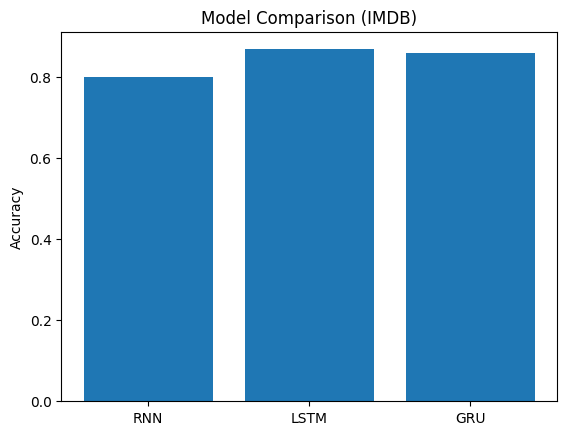

In [13]:
models = ['RNN', 'LSTM', 'GRU']
accuracies = [0.7996, 0.8684, 0.8592]

import matplotlib.pyplot as plt

plt.bar(models, accuracies)
plt.title("Model Comparison (IMDB)")
plt.ylabel("Accuracy")
plt.show()